In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

# Dataset: Dry Bean

### Url: https://www.kaggle.com/datasets/sansuthi/dry-bean-dataset

In [2]:
df = pd.read_csv("data/Dry_Bean.csv")

random_seed = 42

print(df.shape)

print(df.info(), df.describe())

df.head()

(13611, 17)
<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [3]:
info = pd.DataFrame(index=["var", "skew", "kurt"], columns=df.columns[:-1])

for col in df.columns[:-1]:
    var = df[col].var()
    skew = df[col].skew()
    kurt = df[col].kurt()
    info[col] = [var, skew, kurt]

info = pd.concat([df.describe(), info])    

info


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,1.361100e+04,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,1.361100e+04,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,1.361100e+04,13611.000000,13611.000000
mean,5.304828e+04,855.283459,320.141867,202.270714,1.583242,0.750895,5.376820e+04,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,1.715947e-03,0.643590,0.995063
std,2.932410e+04,214.289696,85.694186,44.970091,0.246678,0.092002,2.977492e+04,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,5.958749e-04,0.098996,0.004366
min,2.042000e+04,524.736000,183.601165,122.512653,1.024868,0.218951,2.068400e+04,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,5.641690e-04,0.410339,0.947687
25%,3.632800e+04,703.523500,253.303633,175.848170,1.432307,0.715928,3.671450e+04,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,1.153520e-03,0.581359,0.993703
50%,4.465200e+04,794.941000,296.883367,192.431733,1.551124,0.764441,4.517800e+04,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,1.693531e-03,0.642044,0.996386
75%,6.133200e+04,977.213000,376.495012,217.031741,1.707109,0.810466,6.229400e+04,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,2.170268e-03,0.696006,0.997883
max,2.546160e+05,1985.370000,738.860154,460.198497,2.430306,0.911423,2.632610e+05,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,3.664972e-03,0.974767,0.999733
var,8.599026e+08,45920.073765,7343.493507,2022.309111,0.060850,0.008464,8.865456e+08,3501.931549,0.002409,0.000022,0.003543,0.003809,0.000001,3.550668e-07,0.009800,0.000019
skew,2.952931e+00,1.626124,1.357815,2.238211,0.582573,-1.062824,2.941821e+00,1.948958,-0.895348,-2.550093,-0.635749,0.037115,-0.534141,3.012259e-01,0.242481,-2.759483


In [4]:
classes = df["Class"].unique()

targets = df["Class"].replace({val: i for i, val in enumerate(classes)}).astype(int)

X = df.drop("Class", axis=1)

## Матрица корреляций и визуализация распределения классов

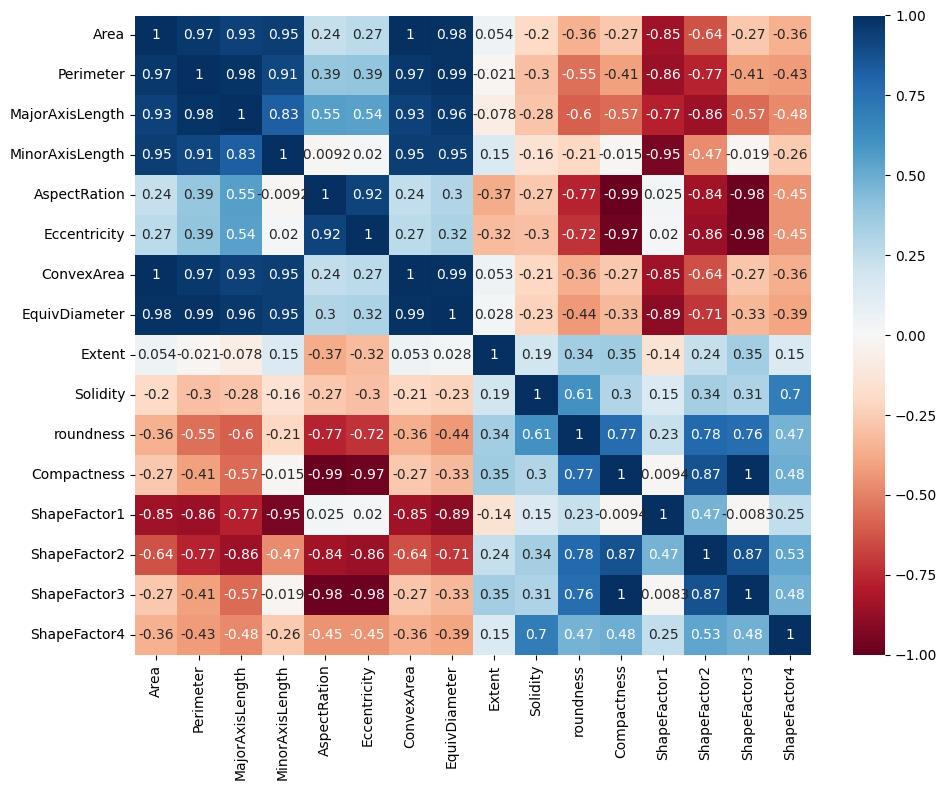

In [5]:
plt.figure(figsize=(10, 8))

sns.heatmap(data=df.corr(numeric_only=True), cmap="RdBu", vmin=-1, vmax=1, annot=True)

plt.tight_layout()

plt.show()

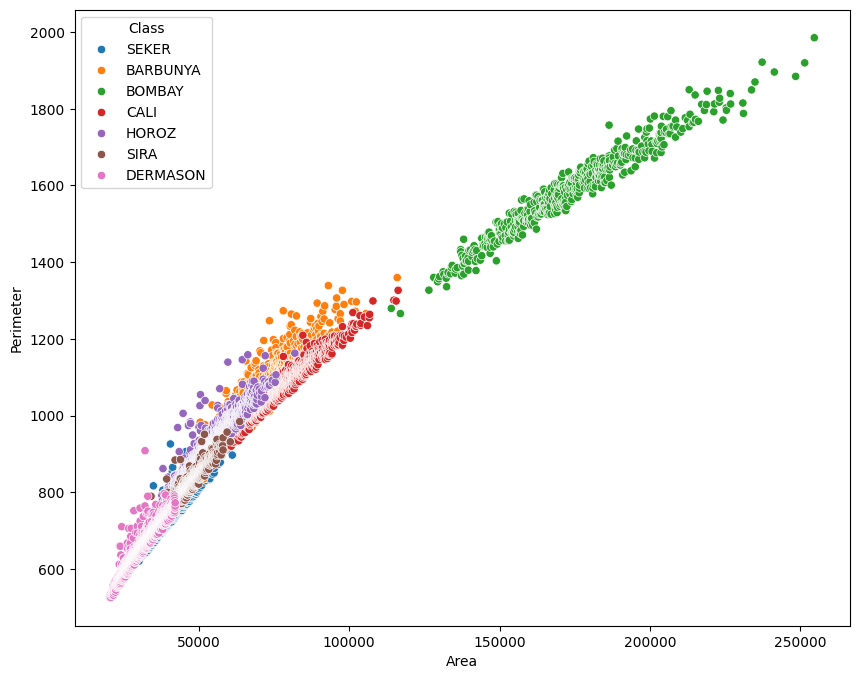

In [6]:
plt.figure(figsize=(10, 8))

sns.scatterplot(data=df, x = "Area", y = "Perimeter", hue=targets.replace(dict(enumerate(classes))))

plt.show()

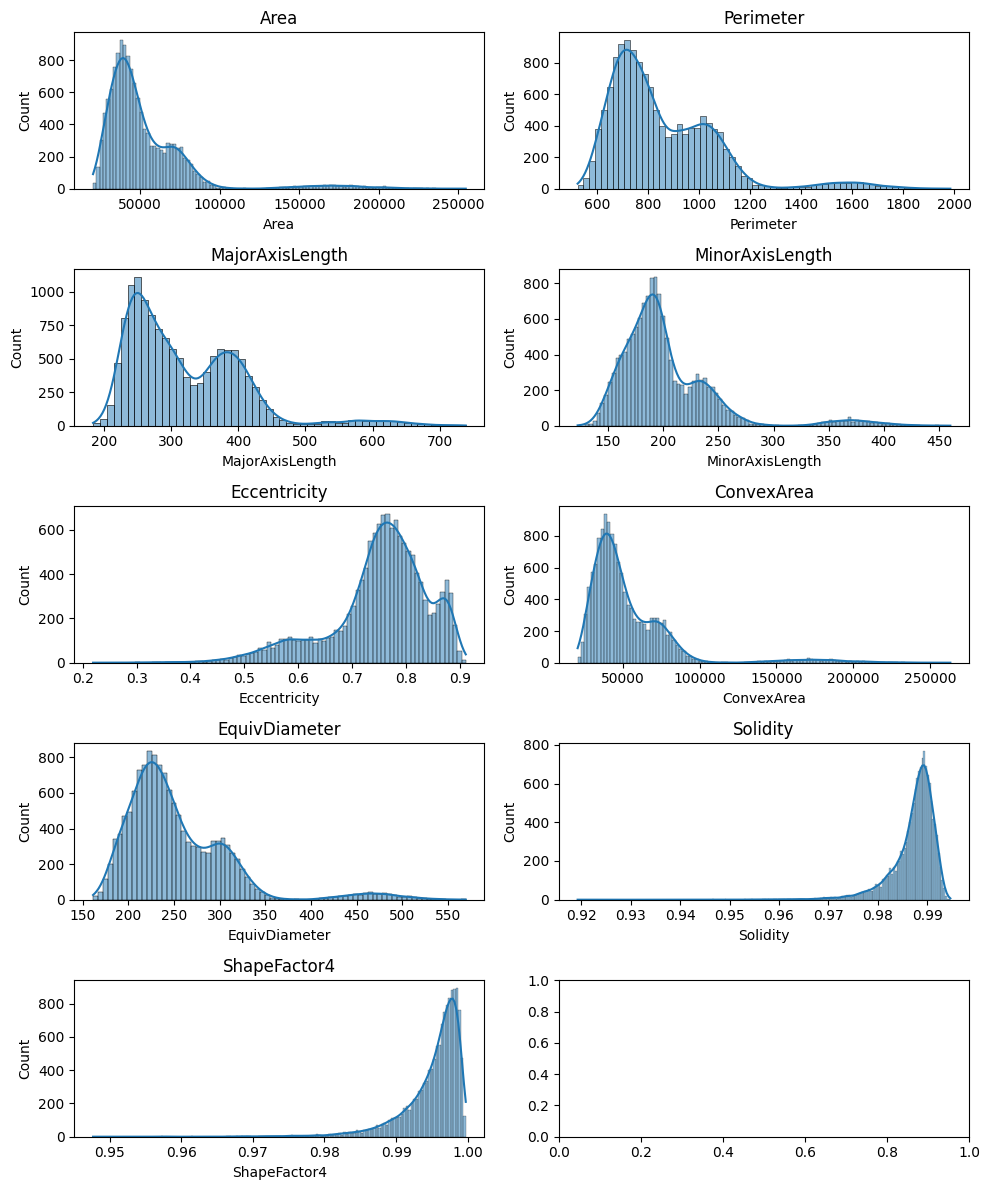

In [7]:
cols_to_hist = info.columns[np.abs(info.loc["skew"])>1]

fig,axes = plt.subplots(5,2, figsize=(10,12))

axes = axes.flatten()

for ax, col in list(zip(axes, cols_to_hist)):

    sns.histplot(df[col], ax=ax, kde=True)

    ax.set_title(col)

plt.tight_layout()

plt.show()

## Пайплайн на препроцессинг

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, targets, test_size=0.3, random_state=random_seed)

transformer = PowerTransformer(standardize=False)

X_train[["Solidity","ShapeFactor4"]] = transformer.fit_transform(X=X_train[["Solidity","ShapeFactor4"]])


In [9]:
X_train[["Solidity","ShapeFactor4"]].skew().reset_index()

,index,0
0,Solidity,-0.964705
1,ShapeFactor4,-1.313641


In [10]:
scaler = StandardScaler()

X_train_scaling = scaler.fit_transform(X_train)

In [11]:
X_test[["Solidity","ShapeFactor4"]] = transformer.fit_transform(X=X_test[["Solidity","ShapeFactor4"]])

X_test_scaling = scaler.transform(X_test)

# Кросс валидация

- ### Distance

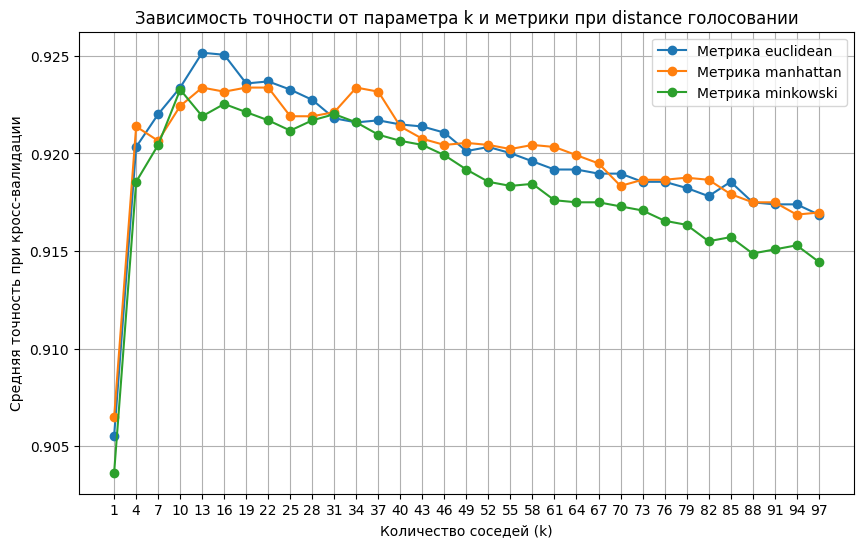

In [12]:
k_range = range(1, 100, 3)
metrics = ['euclidean', 'manhattan', 'minkowski']
cv_scores = dict()

for metric in metrics:
    cv_scores[metric] = []
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=3, n_jobs=100, weights="distance")
        scores = cross_val_score(knn, X_train_scaling, y_train, scoring='accuracy', cv=5, n_jobs=100)
        cv_scores[metric].append(scores.mean())

plt.figure(figsize=(10, 6))
for metric in metrics:
    plt.plot(k_range, cv_scores[metric], marker='o', label=f'Метрика {metric}')

plt.title('Зависимость точности от параметра k и метрики при distance голосовании')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Средняя точность при кросс-валидации')
plt.xticks(k_range)
plt.grid(True)
plt.legend()
plt.show()

- ### Uniform

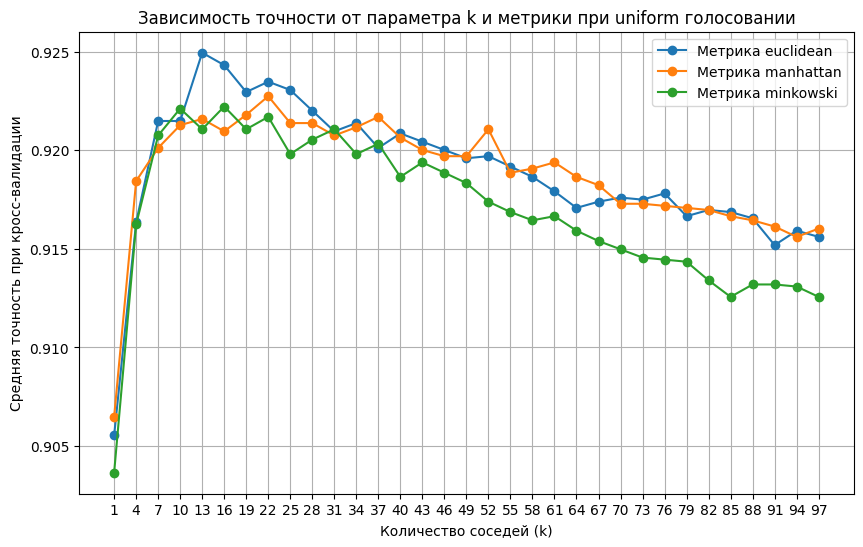

In [13]:
for metric in metrics:
    cv_scores[metric] = []
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=3, n_jobs=100, weights="uniform")
        scores = cross_val_score(knn, X_train_scaling, y_train, scoring='accuracy', cv=5, n_jobs=100)
        cv_scores[metric].append(scores.mean())

plt.figure(figsize=(10, 6))
for metric in metrics:
    plt.plot(k_range, cv_scores[metric], marker='o', label=f'Метрика {metric}')

plt.title('Зависимость точности от параметра k и метрики при uniform голосовании')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Средняя точность при кросс-валидации')
plt.xticks(k_range)
plt.grid(True)
plt.legend()
plt.show()

## Визуализация score

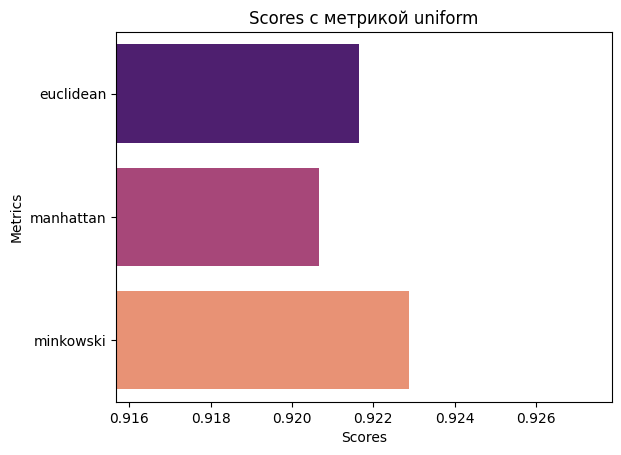

In [24]:
k_uni_max = k_dist_max = 19 

scores = []

for metric in metrics:
    knn = KNeighborsClassifier(n_neighbors=k_uni_max, p=3, weights="uniform", metric=metric, n_jobs=100)
    knn.fit(X_train_scaling, y_train)
    scores.append(knn.score(X_test_scaling, y_test))

sns.barplot(x=scores, y=metrics, palette="magma", hue=metrics)

plt.title("Scores с метрикой uniform")
plt.ylabel("Metrics")
plt.xlabel("Scores")
plt.xlim(min(scores) - 0.005, max(scores) + 0.005)

plt.show()


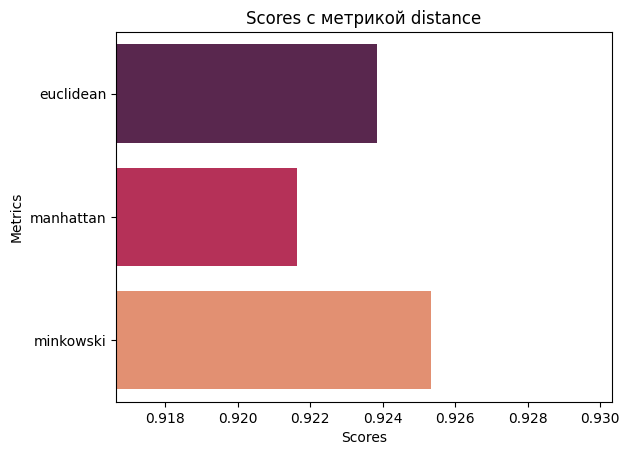

In [25]:
scores = []

for metric in metrics:
    knn = KNeighborsClassifier(n_neighbors=k_dist_max, p=3, weights="distance", metric=metric, n_jobs=100)
    knn.fit(X_train_scaling, y_train)
    scores.append(knn.score(X_test_scaling, y_test))

sns.barplot(x=scores, y=metrics, palette="rocket", hue=metrics)

plt.title("Scores с метрикой distance")
plt.ylabel("Metrics")
plt.xlabel("Scores")
plt.xlim(min(scores) - 0.005, max(scores) + 0.005)

plt.show()

Так, ну в общем че могу сказать по поводу датасета и knn, у нас, если посмотреть на распределение классов, то можно увидеть, что большинство наслаиваются друг на друга, поэтому distance голосование будет лучше, что мы и увидем в последствии на гарфиках, по распределению у нас есть у скошенных признаков два горба, то есть 2 моды, собственно выделяется класс зелененьких бобов(см. scatterplot), c ними нничего не сделаешь, поэтому оставляем как есть, на двух последних histах у нас распределение скошено влево, поэтому юзаем PowerTransform и после него стало лучше, как минимум модуль ассиметрии упал на 1.5, дальше просто кроссвалидируем и визуализируеи результат